#### Sets up the entire Python environment by importing every library needed. It also suppresses harmless warning messages, fixes the random seed for reproducibility, and sets a consistent visual theme for all plots in the coursework

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_score, recall_score
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    StratifiedKFold, learning_curve
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120})

#### Reads the two CSV files (student-mat.csv and student-por.csv), prints their dimensions, then inner-joins them on 13 shared demographic columns to find students who appear in both datasets

#### The sep=';' argument is critical because the UCI files use semicolons as delimiters, not commas.

In [2]:
# Dataset: https://archive.ics.uci.edu/dataset/320/student+performance
mat = pd.read_csv("C:/Users/ishwa/Desktop/Coursework submissions/ST 3189/student-mat.csv", sep=";")
por = pd.read_csv("C:/Users/ishwa/Desktop/Coursework submissions/ST 3189/student-por.csv", sep=";")

print(f"Mathematics : {mat.shape[0]} students, {mat.shape[1]} features")
print(f"Portuguese  : {por.shape[0]} students, {por.shape[1]} features")

merge_keys = ["school","sex","age","address","famsize","Pstatus",
              "Medu","Fedu","Mjob","Fjob","reason","nursery","internet"]
both = pd.merge(mat, por, on=merge_keys, suffixes=("_mat","_por"))
for g in ["G3_mat","G3_por"]:
    both[g] = pd.to_numeric(both[g], errors="coerce")
print(f"Students in both subjects : {len(both)}")
print(f"Cross-subject G3 correlation : r = {both['G3_mat'].corr(both['G3_por']):.2f}")

Mathematics : 395 students, 33 features
Portuguese  : 649 students, 33 features
Students in both subjects : 382
Cross-subject G3 correlation : r = 0.48


#### Concatenates both subject files into a single 1,044-row dataset, then transforms all non-numeric columns into numeric form so that sklearn models can process them

#### Two different encoding strategies are used deliberately. Binary columns (yes/no) are label-encoded to 0/1 — a single integer column is sufficient when there are only two categories. Nominal columns with more than two unordered categories (Mjob, Fjob, reason, guardian) are one-hot encoded to avoid implying a false numeric ordering

#### drop_first=True removes one dummy per group to prevent the dummy variable trap (perfect multicollinearity), which would invalidate linear regression coefficients

In [3]:
binary_cols = ["school","sex","address","famsize","Pstatus",
               "schoolsup","famsup","paid","activities",
               "nursery","higher","internet","romantic"]
nominal_cols = ["Mjob","Fjob","reason","guardian"]

mat["subject"] = "Math"
por["subject"] = "Portuguese"
df = pd.concat([mat, por], ignore_index=True)
df.drop(columns=["subject"], inplace=True)

le = LabelEncoder()
df_enc = df.copy()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)
for g in ["G1","G2","G3"]:
    df_enc[g] = pd.to_numeric(df_enc[g], errors="coerce")
df_enc.dropna(inplace=True)
df_enc.reset_index(drop=True, inplace=True)

print(f"Combined encoded dataset : {df_enc.shape[0]} rows x {df_enc.shape[1]} columns")
print(f"Missing values           : {df_enc.isnull().sum().sum()}")
df_enc.describe().round(2)

Combined encoded dataset : 1044 rows x 42 columns
Missing values           : 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,...,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,0.26,0.43,16.73,0.73,0.29,0.88,2.60,2.39,1.52,1.97,...,3.94,3.20,3.16,1.49,2.28,3.54,4.43,11.21,11.25,11.34
std,0.44,0.50,1.24,0.45,0.46,0.32,1.12,1.10,0.73,0.83,...,0.93,1.03,1.15,0.91,1.29,1.42,6.21,2.98,3.29,3.86
min,0.00,0.00,15.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,16.00,0.00,0.00,1.00,2.00,1.00,1.00,1.00,...,4.00,3.00,2.00,1.00,1.00,3.00,0.00,9.00,9.00,10.00
50%,0.00,0.00,17.00,1.00,0.00,1.00,3.00,2.00,1.00,2.00,...,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,11.00
75%,1.00,1.00,18.00,1.00,1.00,1.00,4.00,3.00,2.00,2.00,...,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,1.00,1.00,22.00,1.00,1.00,1.00,4.00,4.00,4.00,4.00,...,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


#### Produces Figure 1 which is a side-by-side histogram and bar chart comparing the grade distributions and failure rates between Mathematics and Portuguese students.

#### The 32.9% vs 15.4% failure rate contrast is one of the report's most important baseline findings. It establishes that Maths is substantially harder to pass and therefore a more challenging prediction target. 

#### This motivates combining both datasets to maximise sample size while noting the imbalance. The overlapping histogram also shows that the Portuguese grade distribution is left-skewed towards higher grades, whereas Maths has a bimodal shape with a cluster at G3=0 (withdrawals).

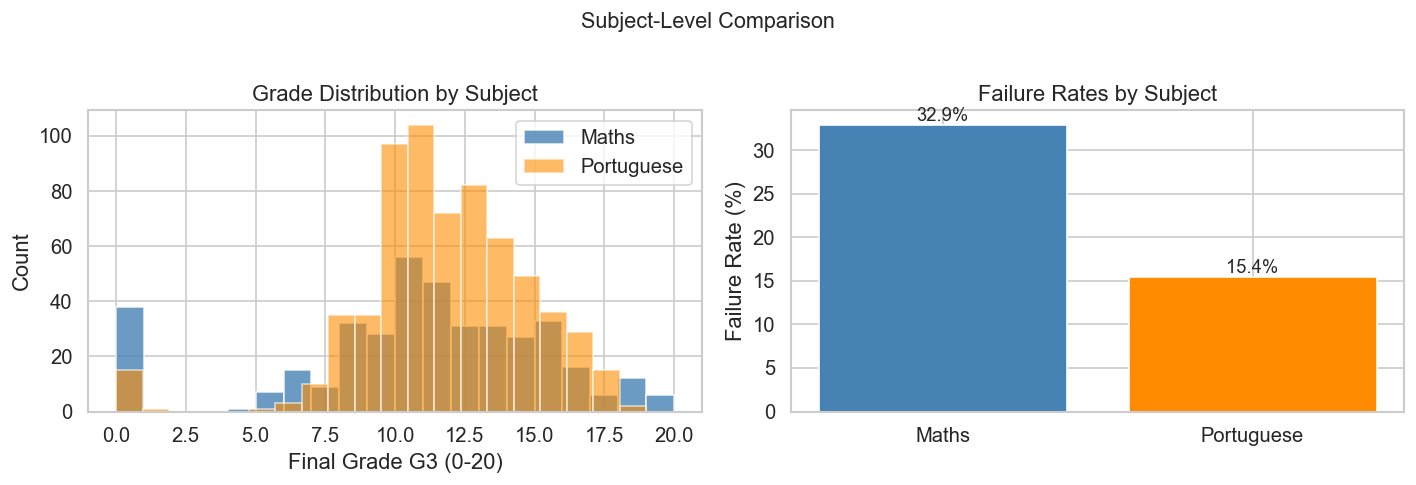

Maths failure rate: 32.9%  |  Portuguese failure rate: 15.4%


In [4]:
mat_g3 = pd.to_numeric(mat["G3"], errors="coerce").dropna()
por_g3 = pd.to_numeric(por["G3"], errors="coerce").dropna()
fail_mat = (mat_g3 < 10).mean() * 100
fail_por = (por_g3 < 10).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mat_g3, bins=20, color="steelblue", edgecolor="white", alpha=0.8, label="Maths")
axes[0].hist(por_g3, bins=20, color="darkorange", edgecolor="white", alpha=0.6, label="Portuguese")
axes[0].set_xlabel("Final Grade G3 (0-20)"); axes[0].set_ylabel("Count")
axes[0].set_title("Grade Distribution by Subject"); axes[0].legend()

axes[1].bar(["Maths","Portuguese"], [fail_mat, fail_por],
            color=["steelblue","darkorange"], edgecolor="white")
axes[1].set_ylabel("Failure Rate (%)")
axes[1].set_title("Failure Rates by Subject")
for i, v in enumerate([fail_mat, fail_por]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)
plt.suptitle("Subject-Level Comparison", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"Maths failure rate: {fail_mat:.1f}%  |  Portuguese failure rate: {fail_por:.1f}%")

#### Computes and visualises a lower-triangle correlation matrix across 16 core numeric features, then prints the top 8 correlates with G3.

#### The coolwarm diverging colour scale makes it easy to spot strong positive (red) and negative (blue) correlations. The key finding visible from this cell is the dominant role of G1 (r=0.81) and G2 (r=0.91) in predicting G3, followed by failures (r=-0.38) as the strongest non-grade predictor. 
#### This directly informs the Scenario A vs B design in code cells 12-13 below.

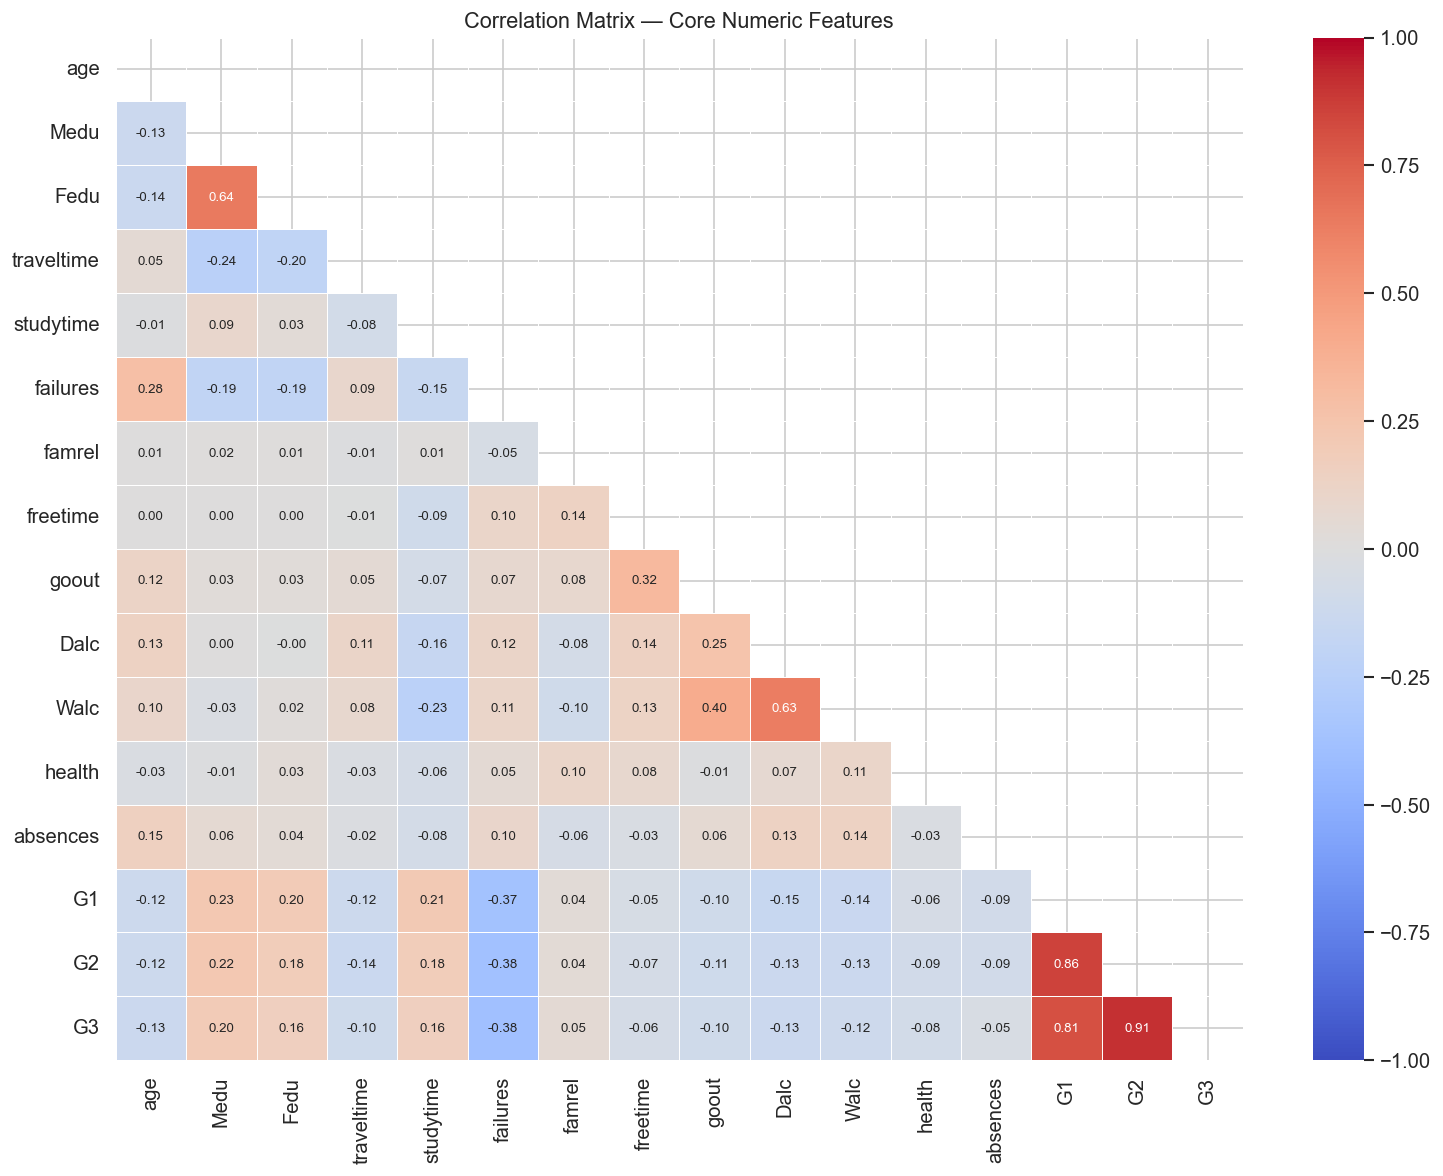

Top correlates with G3:
G2           0.911
G1           0.809
failures     0.383
Medu         0.201
studytime    0.162
Fedu         0.160
Dalc         0.130
age          0.125
Name: G3, dtype: float64


In [5]:
core_numeric = ["age","Medu","Fedu","traveltime","studytime","failures",
                "famrel","freetime","goout","Dalc","Walc","health",
                "absences","G1","G2","G3"]
corr = df_enc[core_numeric].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("Correlation Matrix — Core Numeric Features", fontsize=13)
plt.tight_layout(); plt.show()

print("Top correlates with G3:")
print(corr["G3"].drop("G3").abs().sort_values(ascending=False).head(8).round(3))

#### Creates Figure 3 which is a 2×3 panel of plots showing how each of six key behavioural variables (studytime, failures, Medu, goout, Walc, absences) relate to G3.
#### The code uses different chart types adaptively: discrete ordinal variables (<=6 unique values) get boxplots showing median and IQR per category, while continuous variables (absences) get scatter plots with a regression line and correlation coefficient. 
#### This approach gives the clearest possible visualisation for each variable type. The annotated r value directly from scipy.stats.linregress adds statistical rigour to the visual pattern

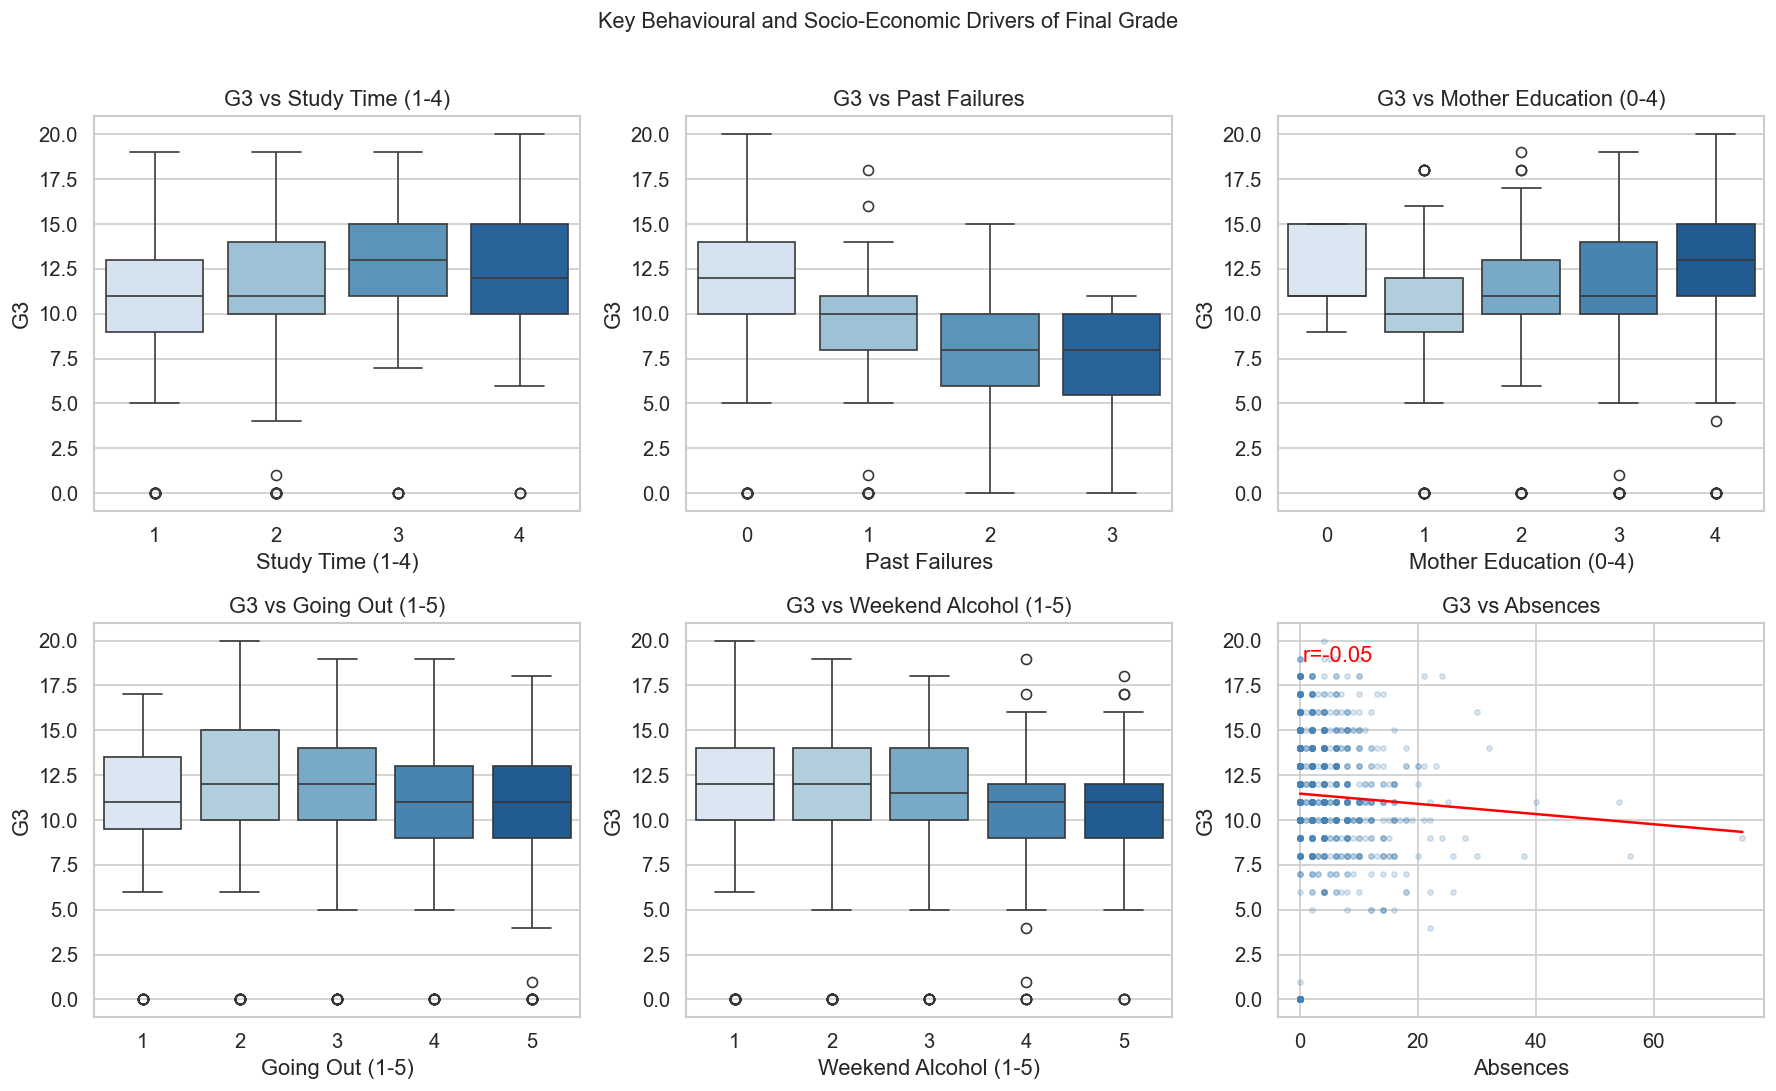

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [
    ("studytime", "Study Time (1-4)"),
    ("failures",  "Past Failures"),
    ("Medu",      "Mother Education (0-4)"),
    ("goout",     "Going Out (1-5)"),
    ("Walc",      "Weekend Alcohol (1-5)"),
    ("absences",  "Absences"),
]
for ax, (feat, label) in zip(axes.flatten(), pairs):
    if df_enc[feat].nunique() <= 6:
        sns.boxplot(x=feat, y="G3", data=df_enc, ax=ax, palette="Blues")
    else:
        ax.scatter(df_enc[feat], df_enc["G3"], alpha=0.2, s=10, color="steelblue")
        m, b, r, _, _ = stats.linregress(df_enc[feat], df_enc["G3"])
        xs = np.linspace(df_enc[feat].min(), df_enc[feat].max(), 100)
        ax.plot(xs, m*xs+b, color="red", lw=1.5)
        ax.text(0.05, 0.9, f"r={r:.2f}", transform=ax.transAxes, color="red")
    ax.set_xlabel(label); ax.set_ylabel("G3"); ax.set_title(f"G3 vs {label}")
plt.suptitle("Key Behavioural and Socio-Economic Drivers of Final Grade",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

#### Produces Figure 4 which has scatter plots of G1 vs G3 and G2 vs G3, with correlation coefficients, plus a count of G3=0 records
#### The near-perfect clustering of points around the diagonal for G2 vs G3 (r=0.91) shows that G2 essentially 'predicts' G3 that a student who scores 14 in G2 almost always scores 13-15 in G3. 
#### This means any model with G2 included will achieve very high R², but this is largely because G2 is a near-replication of G3, not because we have discovered a meaningful causal relationship

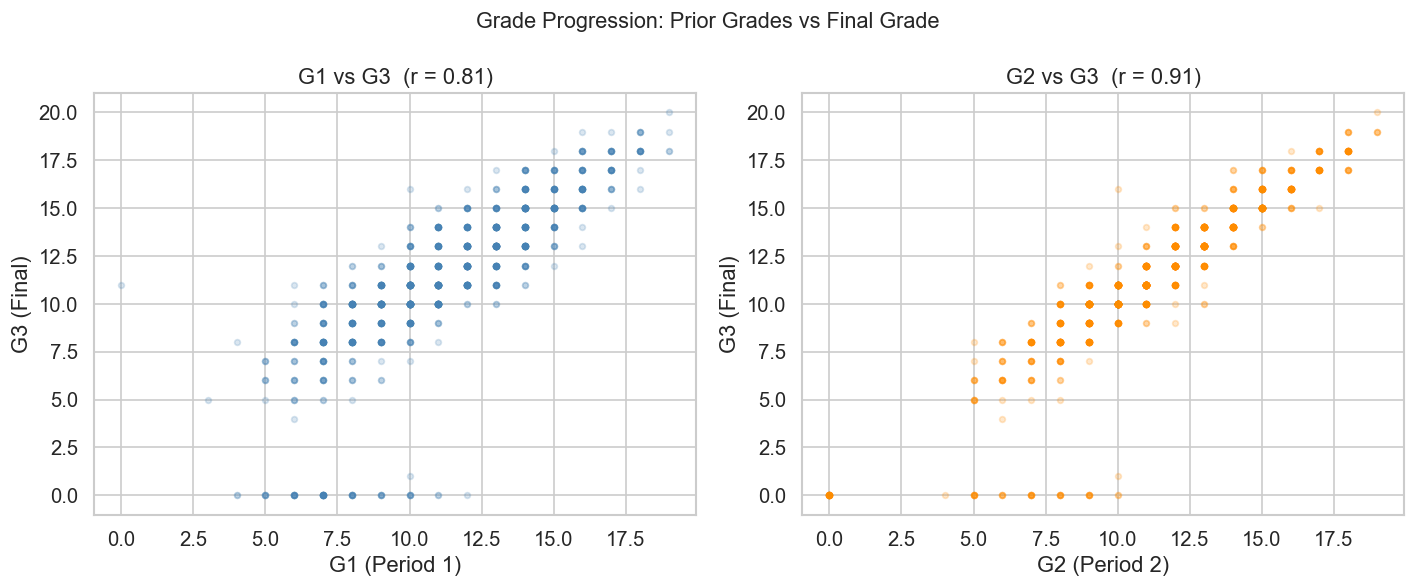

Students with G3=0: 53 (5.1%) — likely withdrawals


In [7]:
g_corr = df_enc[["G1","G2","G3"]].corr()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_enc["G1"], df_enc["G3"], alpha=0.2, s=12, color="steelblue")
axes[0].set_xlabel("G1 (Period 1)"); axes[0].set_ylabel("G3 (Final)")
axes[0].set_title(f"G1 vs G3  (r = {g_corr.loc['G1','G3']:.2f})")
axes[1].scatter(df_enc["G2"], df_enc["G3"], alpha=0.2, s=12, color="darkorange")
axes[1].set_xlabel("G2 (Period 2)"); axes[1].set_ylabel("G3 (Final)")
axes[1].set_title(f"G2 vs G3  (r = {g_corr.loc['G2','G3']:.2f})")
plt.suptitle("Grade Progression: Prior Grades vs Final Grade", fontsize=13)
plt.tight_layout(); plt.show()

zero_g3 = (df_enc["G3"] == 0).sum()
print(f"Students with G3=0: {zero_g3} ({zero_g3/len(df_enc)*100:.1f}%) — likely withdrawals")

#### Fits PCA to the 21 behavioural/demographic features (no grades), plots the scree plot and PC1 loadings, and reduces data to 2D for downstream visualisation.
#### Standardisation before PCA is essential: without it, variables measured in larger units (e.g. absences 0-93) would dominate the principal components over variables measured on a 1-5 scale (e.g. studytime). 
#### The scree plot shows both individual and cumulative explained variance & the red line and 90% threshold help us understand how much information is retained. 
#### The loadings DataFrame lets us label each PC with a easier to interpret name (e.g. PC1 = 'Risk Behaviour') by examining which features have the largest absolute loadings

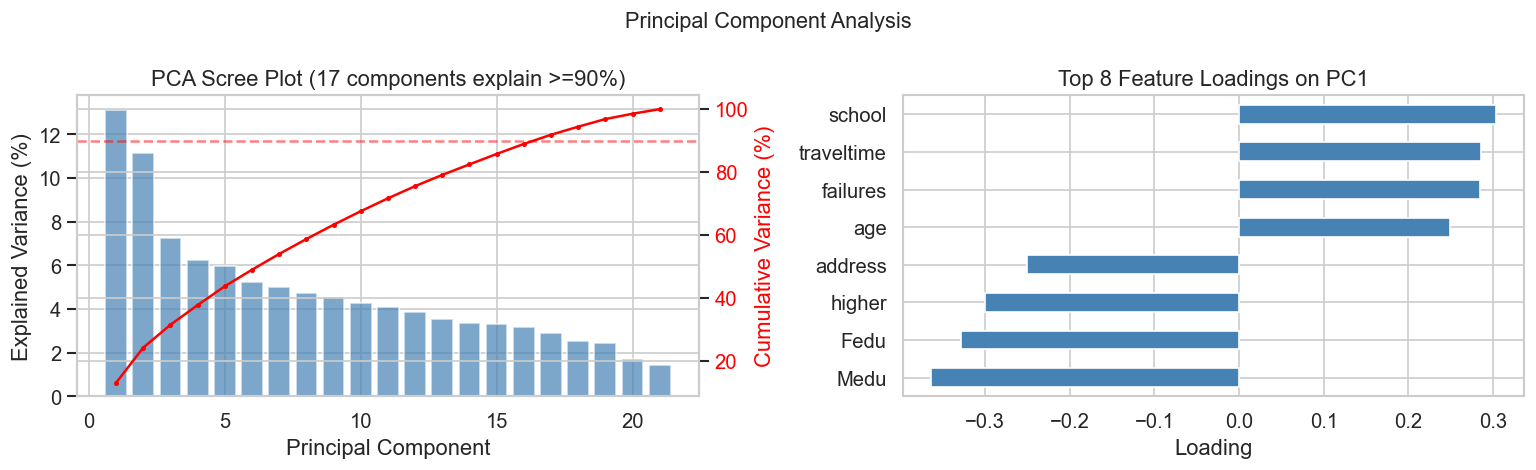

PC1 explains 13.1% of variance
PC1 top loadings:
Medu          0.364
Fedu          0.328
school        0.304
higher        0.300
traveltime    0.285
Name: PC1, dtype: float64


In [8]:
unsup_features = ["age","Medu","Fedu","traveltime","studytime","failures",
                  "famrel","freetime","goout","Dalc","Walc","health",
                  "absences","school","sex","address","internet",
                  "romantic","higher","activities","paid"]

X_unsup = df_enc[unsup_features].copy()
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_unsup)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(cumvar >= 0.90) + 1

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_scaled)
loadings = pd.DataFrame(pca_2d.components_.T, columns=["PC1","PC2"], index=unsup_features)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color="steelblue", alpha=0.7)
ax2 = axes[0].twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar*100, color="red", marker=".", ms=4)
ax2.axhline(90, color="red", linestyle="--", alpha=0.5)
ax2.set_ylabel("Cumulative Variance (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title(f"PCA Scree Plot ({n90} components explain >=90%)")

top_pc1_feats = loadings["PC1"].abs().nlargest(8).index
loadings.loc[top_pc1_feats, "PC1"].sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 8 Feature Loadings on PC1"); axes[1].set_xlabel("Loading")
plt.suptitle("Principal Component Analysis", fontsize=13)
plt.tight_layout(); plt.show()

print(f"PC1 explains {pca_full.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC1 top loadings:\n{loadings['PC1'].abs().sort_values(ascending=False).head(5).round(3)}")

#### Applies K-Means for K=2 through K=10, computes both inertia (elbow) and silhouette score for each K, plots both methods, and fits the optimal K-Means model
#### n_init=10 means K-Means is initialised 10 times with different random centroids and the best result (lowest inertia) is kept which guards against convergence to local minima

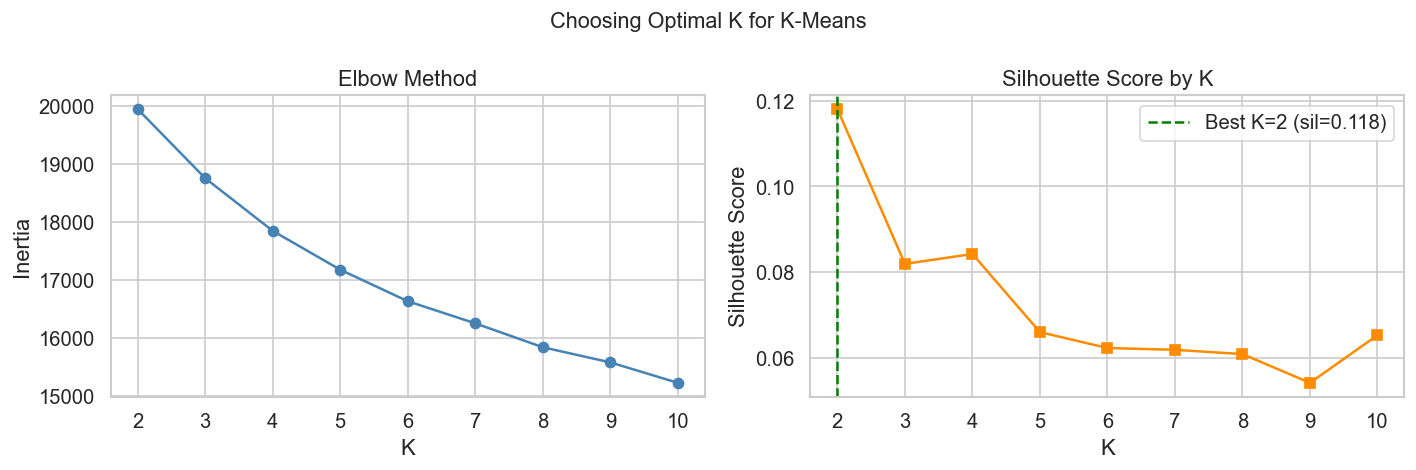

Optimal K = 2  |  Silhouette = 0.1180


In [9]:
inertias, sils = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labs = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labs))

best_k = K_range[np.argmax(sils)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker="o", color="steelblue")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")
axes[1].plot(K_range, sils, marker="s", color="darkorange")
axes[1].axvline(best_k, linestyle="--", color="green",
                label=f"Best K={best_k} (sil={max(sils):.3f})")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K"); axes[1].legend()
plt.suptitle("Choosing Optimal K for K-Means", fontsize=13)
plt.tight_layout(); plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df_enc["cluster"] = cluster_labels
print(f"Optimal K = {best_k}  |  Silhouette = {max(sils):.4f}")

#### Visualises clusters in PCA 2D space and as G3 distributions, runs the Kruskal-Wallis statistical test, and produces the cluster profile summary table and heatmap
#### The Kruskal-Wallis H-test is the non-parametric equivalent of a one-way ANOVA. It tests whether clusters differ significantly in G3 without assuming normality, which is appropriate here since G3 is integer-valued and potentially non-normal

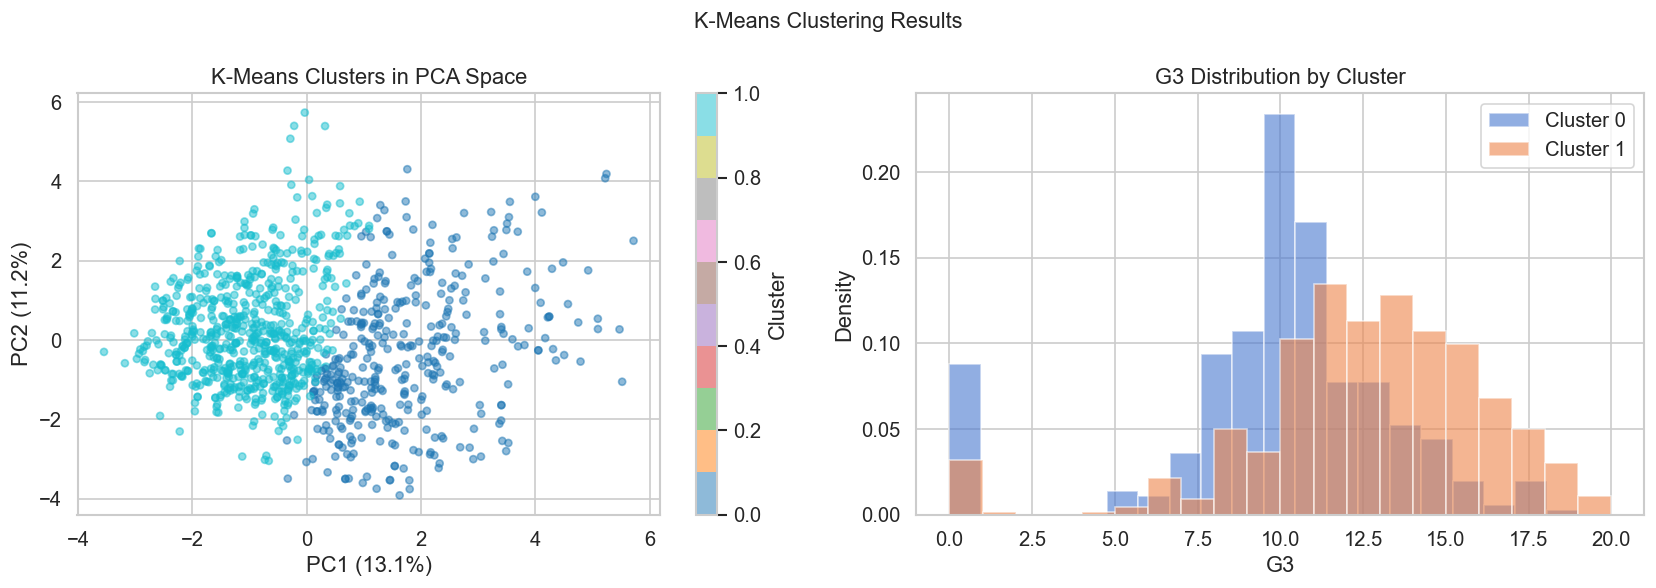

Kruskal-Wallis test: H=106.631, p=0.0000
Clusters differ significantly in G3.

Cluster Profiles:


,age,Medu,Fedu,studytime,failures,goout,Dalc,Walc,absences,G3,N,Pass Rate (%)
cluster,,,,,,,,,,,,
0,17.18,1.78,1.70,1.69,0.55,3.31,1.72,2.57,4.00,9.93,382,66.8
1,16.47,3.08,2.78,2.13,0.10,3.07,1.36,2.12,4.68,12.16,662,84.4


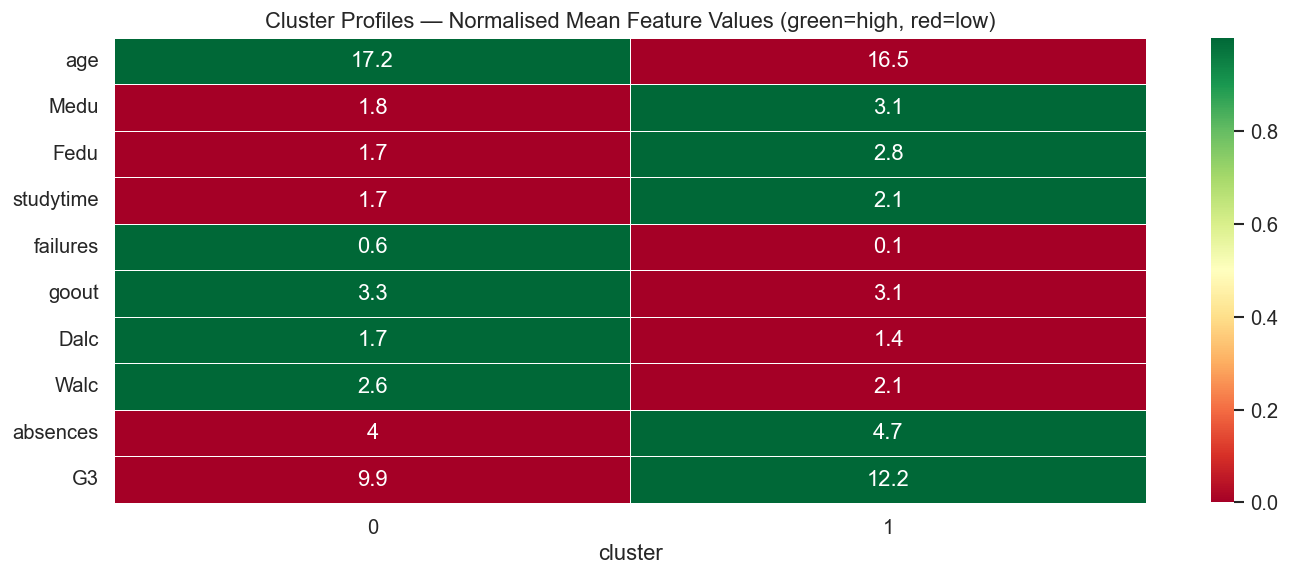

In [10]:
# Visualise clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_pca2[:,0], X_pca2[:,1],
                          c=cluster_labels, cmap="tab10", alpha=0.5, s=18)
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("K-Means Clusters in PCA Space")
plt.colorbar(scatter, ax=axes[0], label="Cluster")
for c in sorted(df_enc["cluster"].unique()):
    axes[1].hist(df_enc.loc[df_enc["cluster"]==c,"G3"],
                 bins=20, alpha=0.6, label=f"Cluster {c}", density=True)
axes[1].set_xlabel("G3"); axes[1].set_ylabel("Density")
axes[1].set_title("G3 Distribution by Cluster"); axes[1].legend()
plt.suptitle("K-Means Clustering Results", fontsize=13)
plt.tight_layout(); plt.show()

cluster_g3 = [df_enc.loc[df_enc["cluster"]==c,"G3"].values
              for c in sorted(df_enc["cluster"].unique())]
stat_kw, p_kw = kruskal(*cluster_g3)
print(f"Kruskal-Wallis test: H={stat_kw:.3f}, p={p_kw:.4f}")
print("Clusters differ significantly in G3." if p_kw < 0.05 else "No significant difference.")

# Cluster profiles
profile_cols = ["age","Medu","Fedu","studytime","failures",
                "goout","Dalc","Walc","absences","G3"]
cluster_profile = df_enc.groupby("cluster")[profile_cols].mean().round(2)
cluster_profile["N"] = df_enc.groupby("cluster").size()
cluster_profile["Pass Rate (%)"] = (
    df_enc.groupby("cluster")["G3"]
    .apply(lambda x: (x >= 10).mean()*100).round(1))
print("\nCluster Profiles:")
display(cluster_profile)

# Heatmap
plt.figure(figsize=(12, 5))
norm_p = (cluster_profile[profile_cols] - cluster_profile[profile_cols].min()) / \
         (cluster_profile[profile_cols].max() - cluster_profile[profile_cols].min() + 1e-9)
sns.heatmap(norm_p.T, annot=cluster_profile[profile_cols].T.round(1),
            fmt="g", cmap="RdYlGn", linewidths=0.5)
plt.title("Cluster Profiles — Normalised Mean Feature Values (green=high, red=low)")
plt.tight_layout(); plt.show()

#### Defines the make_reg_data() function that prepares X and y for regression under either scenario, and builds the list of seven model objects with their configuration.
#### The third element in each model tuple (True/False) flags whether the model requires standardised inputs. Linear, Ridge, Lasso, and SVR are all distance or gradient-based and need standardisation while tree-based models (Decision Tree, Random Forest, Gradient Boosting) are invariant to feature scaling
#### Using this flag avoids accidental data leakage from fitting the scaler on the test set. The function-based approach means the exact same preprocessing logic applies consistently across both scenarios.

In [11]:
def make_reg_data(df, with_grades=True):
    drop = ["G3","cluster"]
    if "pass" in df.columns:
        drop.append("pass")
    if not with_grades:
        drop += ["G1","G2"]
    X = df.drop(columns=[c for c in drop if c in df.columns])
    return X, df["G3"]

reg_models_def = [
    ("Linear Regression",  LinearRegression(),                                           True),
    ("Ridge (alpha=1)",    Ridge(alpha=1.0),                                             True),
    ("Lasso (alpha=0.01)", Lasso(alpha=0.01),                                            True),
    ("Decision Tree",      DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE), False),
    ("Random Forest",      RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), False),
    ("Gradient Boosting",  GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE), False),
    ("SVR (RBF)",          SVR(kernel="rbf", C=10, epsilon=0.5),                         True),
]

#### Trains and evaluates all seven regression models under both Scenario A (with G1/G2) and Scenario B (without G1/G2), stores results, and produces a side-by-side RMSE bar chart.
#### The scaler is fit ONLY on X_tr and then applied to X_te which proper procedure to avoid data leakage. If the scaler were fit on all data, the test set would contain information about the training distribution, artificially inflating test performance.
#### The 5-fold cross-validated RMSE (cv) provides a more reliable estimate of generalisation than the single test RMSE because it averages over 5 different train/validation splits.


--- Scenario: With G1/G2 ---
  Linear Regression       RMSE=1.7898  R2=0.7928  CV-RMSE=1.5383
  Ridge (alpha=1)         RMSE=1.7902  R2=0.7927  CV-RMSE=1.5380
  Lasso (alpha=0.01)      RMSE=1.7766  R2=0.7958  CV-RMSE=1.5263
  Decision Tree           RMSE=1.9504  R2=0.7539  CV-RMSE=1.7145
  Random Forest           RMSE=1.7046  R2=0.8121  CV-RMSE=1.4515
  Gradient Boosting       RMSE=1.6770  R2=0.8181  CV-RMSE=1.4884
  SVR (RBF)               RMSE=2.0019  R2=0.7408  CV-RMSE=1.7659

--- Scenario: Without G1/G2 ---
  Linear Regression       RMSE=3.7496  R2=0.0906  CV-RMSE=3.4590
  Ridge (alpha=1)         RMSE=3.7488  R2=0.0910  CV-RMSE=3.4584
  Lasso (alpha=0.01)      RMSE=3.7417  R2=0.0944  CV-RMSE=3.4461
  Decision Tree           RMSE=4.2085  R2=-0.1456  CV-RMSE=3.4260
  Random Forest           RMSE=3.7021  R2=0.1135  CV-RMSE=3.2036
  Gradient Boosting       RMSE=3.6870  R2=0.1207  CV-RMSE=3.2946
  SVR (RBF)               RMSE=3.3970  R2=0.2536  CV-RMSE=3.3930


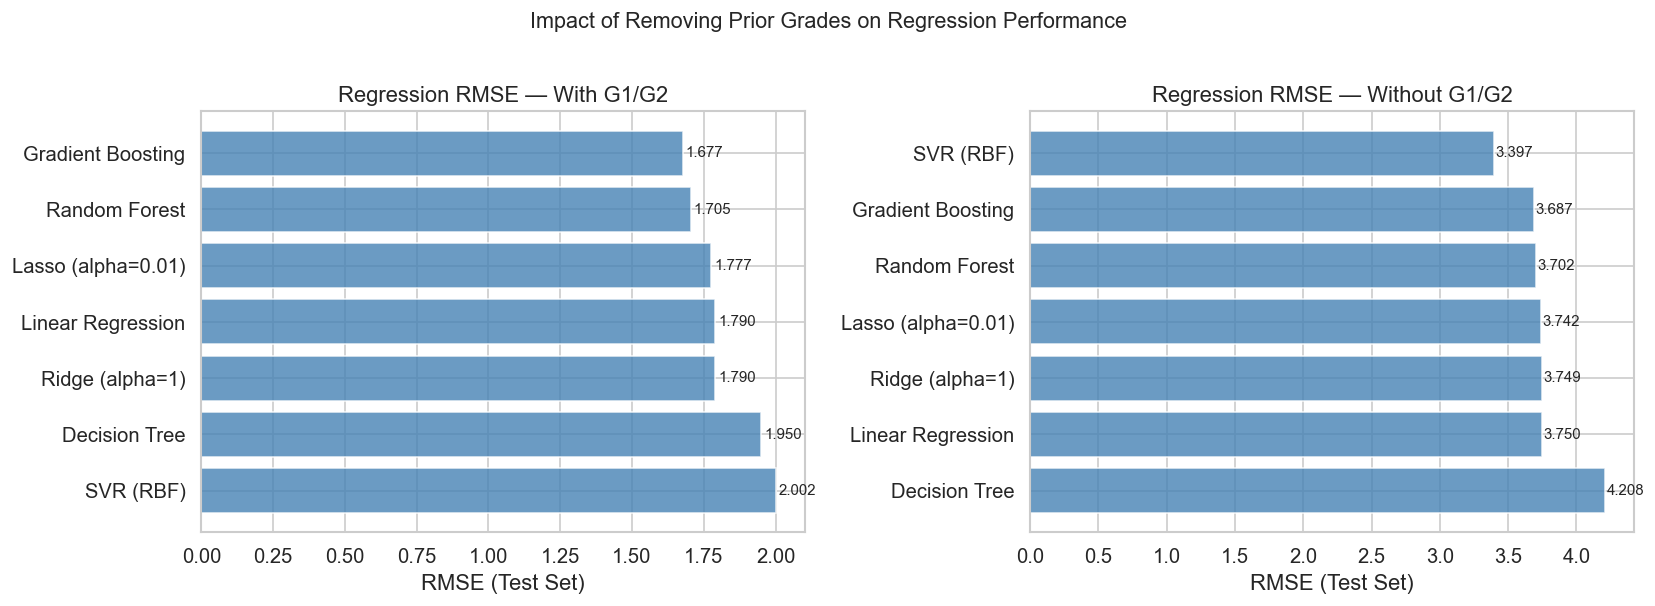


RMSE with G1/G2: 1.6770
RMSE without G1/G2: 3.3970  (+1.7200)
Best R2 without G1/G2: 0.2536


In [12]:
all_reg_tables = {}

for scenario, with_grades in [("With G1/G2", True), ("Without G1/G2", False)]:
    print(f"\n--- Scenario: {scenario} ---")
    X, y = make_reg_data(df_enc, with_grades=with_grades)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)

    rows = []
    for name, model, uses_scale in reg_models_def:
        Xtr_in = X_tr_s if uses_scale else X_tr.values
        Xte_in = X_te_s if uses_scale else X_te.values
        model.fit(Xtr_in, y_tr)
        preds = model.predict(Xte_in)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        mae  = mean_absolute_error(y_te, preds)
        r2   = r2_score(y_te, preds)
        cv   = np.sqrt(-cross_val_score(model, Xtr_in, y_tr, cv=5,
                                         scoring="neg_mean_squared_error")).mean()
        rows.append({"Model":name,"RMSE":round(rmse,4),"MAE":round(mae,4),
                     "R2":round(r2,4),"CV-RMSE":round(cv,4)})
        print(f"  {name:<22}  RMSE={rmse:.4f}  R2={r2:.4f}  CV-RMSE={cv:.4f}")

    tbl = pd.DataFrame(rows).sort_values("RMSE")
    all_reg_tables[scenario] = (tbl, y_te, X_tr, y_tr, X_te, sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (scenario, (tbl,*_)) in zip(axes, all_reg_tables.items()):
    ax.barh(tbl["Model"][::-1], tbl["RMSE"][::-1], color="steelblue", alpha=0.8)
    ax.set_xlabel("RMSE (Test Set)"); ax.set_title(f"Regression RMSE — {scenario}")
    for i, (_, row) in enumerate(tbl[::-1].iterrows()):
        ax.text(row["RMSE"]+0.01, i, f"{row['RMSE']:.3f}", va="center", fontsize=9)
plt.suptitle("Impact of Removing Prior Grades on Regression Performance", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

rmse_with    = all_reg_tables["With G1/G2"][0]["RMSE"].min()
rmse_without = all_reg_tables["Without G1/G2"][0]["RMSE"].min()
r2_without   = all_reg_tables["Without G1/G2"][0]["R2"].max()
print(f"\nRMSE with G1/G2: {rmse_with:.4f}")
print(f"RMSE without G1/G2: {rmse_without:.4f}  (+{rmse_without-rmse_with:.4f})")
print(f"Best R2 without G1/G2: {r2_without:.4f}")

#### Uses 5-fold GridSearchCV to find the optimal combination of n_estimators, max_depth, and min_samples_leaf for Random Forest under Scenario A.
#### GridSearchCV exhaustively tries every combination of the supplied parameter values: 3 × 3 × 3 = 27 combinations, each fitted 5 times (cross-validation) = 135 model fits total. n_jobs=-1 uses all available CPU cores in parallel to speed this up. 

In [13]:
X_full, y_full = make_reg_data(df_enc, with_grades=True)
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE)

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    {"n_estimators":[100,200,300], "max_depth":[None,5,10],
     "min_samples_leaf":[1,2,4]},
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=0
)
rf_gs.fit(X_tr_f, y_tr_f)
best_rf = rf_gs.best_estimator_
preds_tuned = best_rf.predict(X_te_f)
rmse_tuned  = np.sqrt(mean_squared_error(y_te_f, preds_tuned))
r2_tuned    = r2_score(y_te_f, preds_tuned)
print(f"Best params : {rf_gs.best_params_}")
print(f"Tuned RF    : RMSE={rmse_tuned:.4f}, R2={r2_tuned:.4f}")

Best params : {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 300}
Tuned RF    : RMSE=1.6694, R2=0.8197


#### Produces a three-panel diagnostic figure for the tuned Random Forest: actual vs predicted scatter, residuals vs fitted values, and a residual histogram with Shapiro-Wilk test.

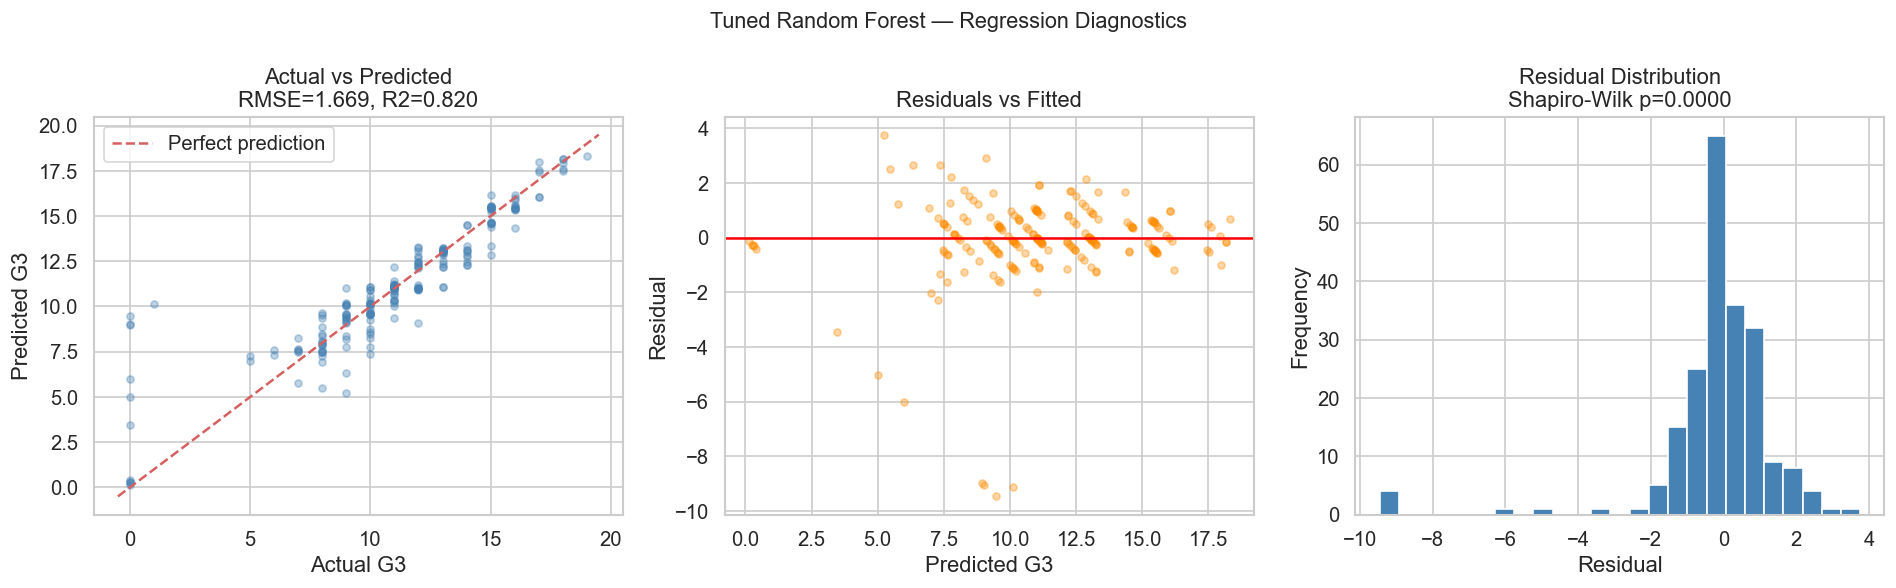

In [14]:
resid = y_te_f - preds_tuned
_, p_norm = stats.shapiro(resid.values[:500])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(y_te_f, preds_tuned, alpha=0.35, s=18, color="steelblue")
lims = [min(y_te_f.min(), preds_tuned.min())-0.5,
        max(y_te_f.max(), preds_tuned.max())+0.5]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual G3"); axes[0].set_ylabel("Predicted G3")
axes[0].set_title(f"Actual vs Predicted\nRMSE={rmse_tuned:.3f}, R2={r2_tuned:.3f}")
axes[0].legend()

axes[1].scatter(preds_tuned, resid, alpha=0.35, s=18, color="darkorange")
axes[1].axhline(0, color="red", lw=1.5)
axes[1].set_xlabel("Predicted G3"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted")

axes[2].hist(resid, bins=25, color="steelblue", edgecolor="white")
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Frequency")
axes[2].set_title(f"Residual Distribution\nShapiro-Wilk p={p_norm:.4f}")
plt.suptitle("Tuned Random Forest — Regression Diagnostics", fontsize=13)
plt.tight_layout(); plt.show()

#### Computes permutation importance (15 repeats) for the top 20 features, then plots a learning curve showing training vs cross-validation RMSE as a function of training set size
#### Permutation importance is preferred over Gini (mean decrease in impurity) because it measures actual impact on test-set performance. Each feature is randomly shuffled in turn, and the drop in R² is recorded
#### n_repeats=15 means this shuffle is repeated 15 times per feature, giving a mean and standard deviation & the error bars on the chart show this uncertainty


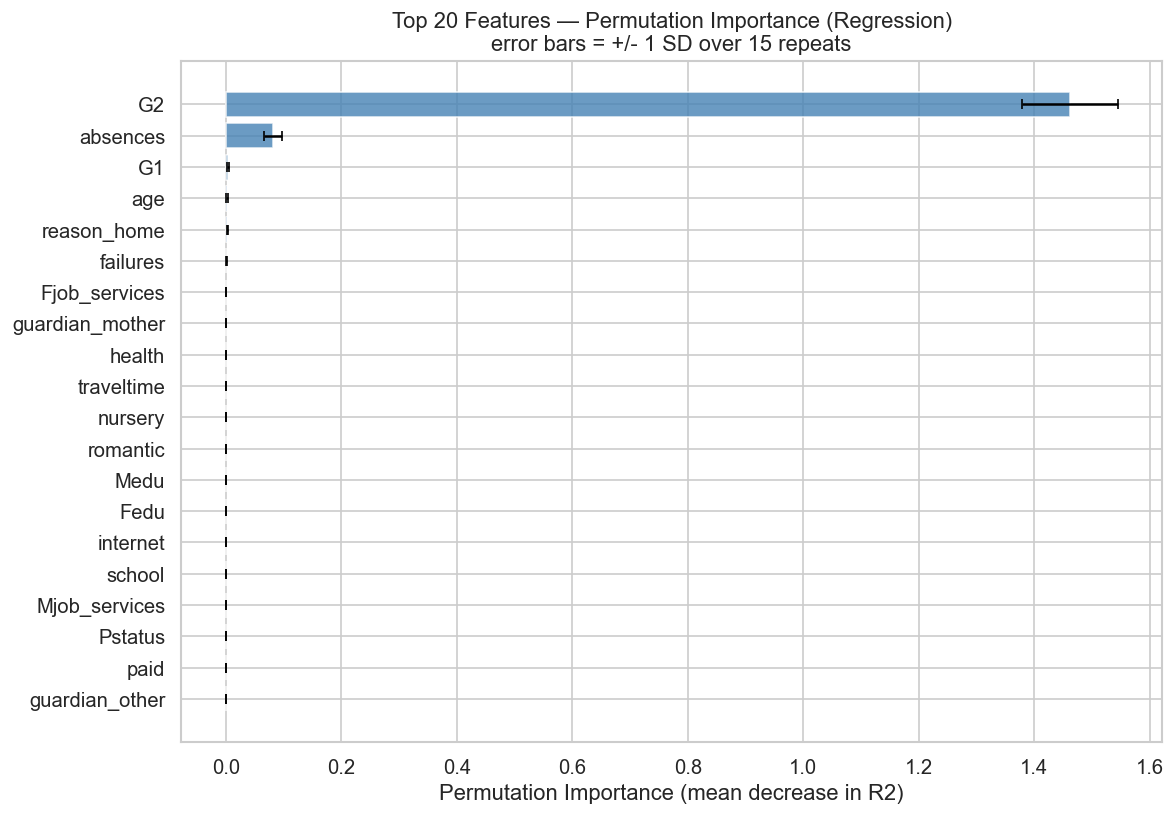

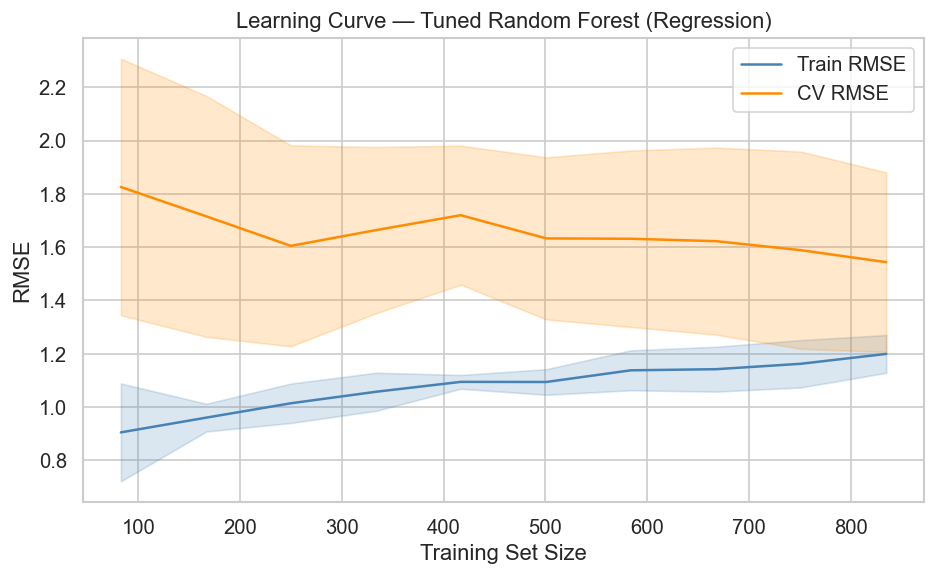

In [15]:
perm_imp = permutation_importance(best_rf, X_te_f, y_te_f,
                                  n_repeats=15, random_state=RANDOM_STATE)
perm_df = pd.DataFrame({
    "Feature":    X_full.columns,
    "Importance": perm_imp.importances_mean,
    "Std":        perm_imp.importances_std
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(perm_df["Feature"].values[::-1], perm_df["Importance"].values[::-1],
         xerr=perm_df["Std"].values[::-1], color="steelblue", alpha=0.8,
         capsize=3, ecolor="black")
plt.xlabel("Permutation Importance (mean decrease in R2)")
plt.title("Top 20 Features — Permutation Importance (Regression)\nerror bars = +/- 1 SD over 15 repeats")
plt.tight_layout(); plt.show()

train_sizes, train_sc, val_sc = learning_curve(
    RandomForestRegressor(**rf_gs.best_params_, random_state=RANDOM_STATE),
    X_full, y_full, cv=5, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, -train_sc.mean(axis=1), label="Train RMSE", color="steelblue")
plt.fill_between(train_sizes,
                 -train_sc.mean(1)-train_sc.std(1),
                 -train_sc.mean(1)+train_sc.std(1), alpha=0.2, color="steelblue")
plt.plot(train_sizes, -val_sc.mean(axis=1), label="CV RMSE", color="darkorange")
plt.fill_between(train_sizes,
                 -val_sc.mean(1)-val_sc.std(1),
                 -val_sc.mean(1)+val_sc.std(1), alpha=0.2, color="darkorange")
plt.xlabel("Training Set Size"); plt.ylabel("RMSE")
plt.title("Learning Curve — Tuned Random Forest (Regression)")
plt.legend(); plt.tight_layout(); plt.show()

#### Creates the binary pass/fail target column, prints the class distribution and naive baseline, and defines the six classifier models to be compared.
#### The 78% naive baseline gives critical context that any classifier that simply predicts 'pass' for every student achieves 78% accuracy without learning anything. This exposes accuracy as a misleading metric for imbalanced classes

In [16]:
df_enc["pass"] = (df_enc["G3"] >= 10).astype(int)
pass_rate = df_enc["pass"].mean()
print(f"Pass rate: {pass_rate*100:.1f}%  (Pass={df_enc['pass'].sum()}, Fail={(df_enc['pass']==0).sum()})")
print(f"Baseline accuracy (always predict pass): {pass_rate*100:.1f}%")

clf_models_def = [
    ("Logistic Regression",  LogisticRegression(max_iter=500, random_state=RANDOM_STATE), True),
    ("Decision Tree",        DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE), False),
    ("Random Forest",        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    ("Gradient Boosting",    GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    ("SVM (RBF)",            SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE), True),
    ("K-Nearest Neighbours", KNeighborsClassifier(n_neighbors=7), True),
]

Pass rate: 78.0%  (Pass=814, Fail=230)
Baseline accuracy (always predict pass): 78.0%


#### Trains and evaluates all six classifiers under both scenarios using stratified splits, computes Accuracy/F1/Recall/AUC, and tunes Random Forest via GridSearchCV for each scenario
#### stratify=y_c in train_test_split ensures both train and test sets have the same 78/22 pass/fail ratio as the full dataset since without this, random splitting could produce a test set with an unrepresentative proportion of failures, giving misleading evaluation

In [17]:
clf_results_store = {}
tuned_clf = {}

for scenario, with_grades in [("With G1/G2", True), ("Without G1/G2", False)]:
    print(f"\n--- Scenario: {scenario} ---")
    drop_c = ["G3","pass","cluster"] + ([] if with_grades else ["G1","G2"])
    X_c = df_enc.drop(columns=[c for c in drop_c if c in df_enc.columns])
    y_c = df_enc["pass"]
    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
        X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c)
    sc_c = StandardScaler()
    X_tr_cs = sc_c.fit_transform(X_tr_c); X_te_cs = sc_c.transform(X_te_c)

    rows_c = []
    for name, model, uses_scale in clf_models_def:
        Xtr_in = X_tr_cs if uses_scale else X_tr_c.values
        Xte_in = X_te_cs if uses_scale else X_te_c.values
        model.fit(Xtr_in, y_tr_c)
        preds_c = model.predict(Xte_in)
        probas  = model.predict_proba(Xte_in)[:,1] if hasattr(model,"predict_proba") else None
        acc  = accuracy_score(y_te_c, preds_c)
        f1   = f1_score(y_te_c, preds_c)
        rec  = recall_score(y_te_c, preds_c)
        roc_val = auc(*roc_curve(y_te_c, probas)[:2]) if probas is not None else np.nan
        cv_f1 = cross_val_score(model, Xtr_in, y_tr_c, cv=5, scoring="f1").mean()
        rows_c.append({"Model":name,"Accuracy":round(acc,4),"F1":round(f1,4),
                       "Recall":round(rec,4),"AUC":round(roc_val,4),"CV-F1":round(cv_f1,4),
                       "_model":model,"_proba":probas,"_preds":preds_c,"_y_te":y_te_c})
        print(f"  {name:<22}  Acc={acc:.4f}  F1={f1:.4f}  Rec={rec:.4f}  AUC={roc_val:.4f}")

    clf_results_store[scenario] = rows_c

    print(f"  Tuning RF ({scenario})...")
    gs_c = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators":[100,200,300],"max_depth":[None,5,10],"min_samples_leaf":[1,2,4]},
        cv=StratifiedKFold(5), scoring="f1", n_jobs=-1
    )
    gs_c.fit(X_tr_c, y_tr_c)
    best_rfc = gs_c.best_estimator_
    preds_t  = best_rfc.predict(X_te_c)
    proba_t  = best_rfc.predict_proba(X_te_c)[:,1]
    print(f"  Best params: {gs_c.best_params_}")
    print(f"  Tuned RF: Acc={accuracy_score(y_te_c,preds_t):.4f}  "
          f"F1={f1_score(y_te_c,preds_t):.4f}  AUC={auc(*roc_curve(y_te_c,proba_t)[:2]):.4f}")
    print(f"\n  Classification Report ({scenario}):")
    print(classification_report(y_te_c, preds_t, target_names=["Fail","Pass"]))
    tuned_clf[scenario] = (best_rfc, X_te_c, y_te_c, preds_t, proba_t)


--- Scenario: With G1/G2 ---
  Logistic Regression     Acc=0.9139  F1=0.9448  Rec=0.9448  AUC=0.9593
  Decision Tree           Acc=0.9187  F1=0.9489  Rec=0.9693  AUC=0.9046
  Random Forest           Acc=0.9043  F1=0.9390  Rec=0.9448  AUC=0.9538
  Gradient Boosting       Acc=0.8995  F1=0.9358  Rec=0.9387  AUC=0.9409
  SVM (RBF)               Acc=0.8995  F1=0.9381  Rec=0.9755  AUC=0.9365
  K-Nearest Neighbours    Acc=0.8038  F1=0.8845  Rec=0.9632  AUC=0.7914
  Tuning RF (With G1/G2)...
  Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300}
  Tuned RF: Acc=0.8995  F1=0.9362  AUC=0.9560

  Classification Report (With G1/G2):
              precision    recall  f1-score   support

        Fail       0.79      0.74      0.76        46
        Pass       0.93      0.94      0.94       163

    accuracy                           0.90       209
   macro avg       0.86      0.84      0.85       209
weighted avg       0.90      0.90      0.90       209


--- Scenario: With

#### Plots ROC curves for all classifiers in both scenarios on a 1×2 subplot, including the tuned Random Forest as a bold dashed reference line.
#### The ROC curve plots the True Positive Rate against the False Positive Rate across all possible classification thresholds.
#### The diagonal dotted line represents a random classifier (AUC=0.5). A curve that hugs the top-left corner indicates a model that can achieve high sensitivity without high false alarm rates. 

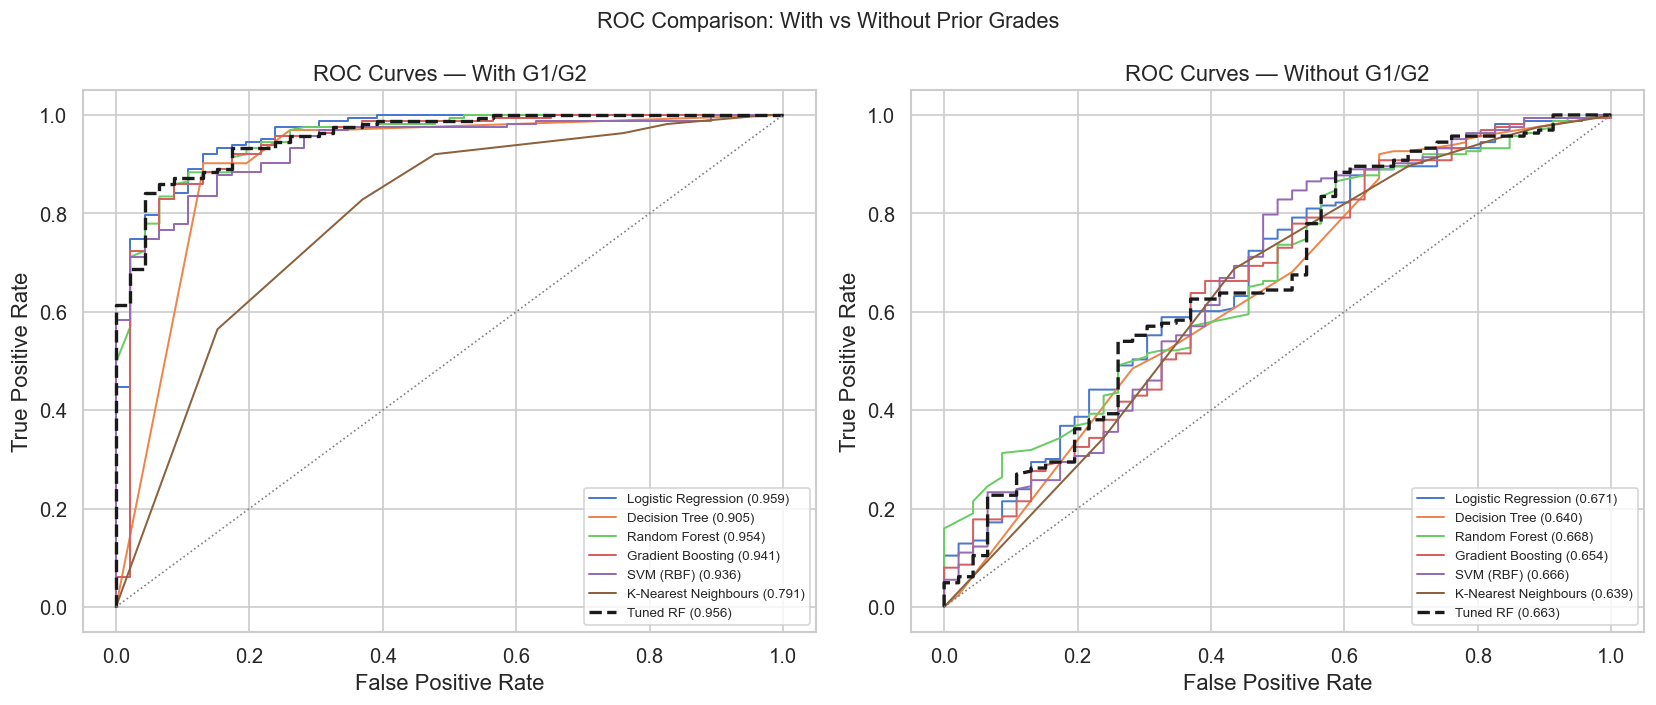

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (scenario, rows_c) in zip(axes, clf_results_store.items()):
    y_te_c = rows_c[0]["_y_te"]
    for r in rows_c:
        if r["_proba"] is not None:
            fpr, tpr, _ = roc_curve(y_te_c, r["_proba"])
            ax.plot(fpr, tpr, lw=1.2, label=f"{r['Model']} ({r['AUC']:.3f})")
    _, _, y_te_c2, _, proba_t = tuned_clf[scenario]
    fpr_t, tpr_t, _ = roc_curve(y_te_c2, proba_t)
    ax.plot(fpr_t, tpr_t, "k--", lw=2, label=f"Tuned RF ({auc(fpr_t,tpr_t):.3f})")
    ax.plot([0,1],[0,1],":", color="gray", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curves — {scenario}"); ax.legend(fontsize=8, loc="lower right")
plt.suptitle("ROC Comparison: With vs Without Prior Grades", fontsize=13)
plt.tight_layout(); plt.show()

#### Produces Figure 14 which is an annotated confusion matrices for the tuned Random Forest under both scenarios, using different colour maps to distinguish the scenarios visually.
#### The confusion matrix shows four cells: True Negative (correctly predicted fail), False Positive (predicted pass, actually failed which is dangerous in a real system), False Negative (predicted fail, actually passed which shows unnecessary intervention), and True Positive (correctly predicted pass). 
#### In an early warning context, False Negatives (missing at-risk students) are the most costly error. The matrices make this asymmetry visible since comparing the top-left cell across scenarios shows how many fewer failing students are caught when G1/G2 are unavailable.

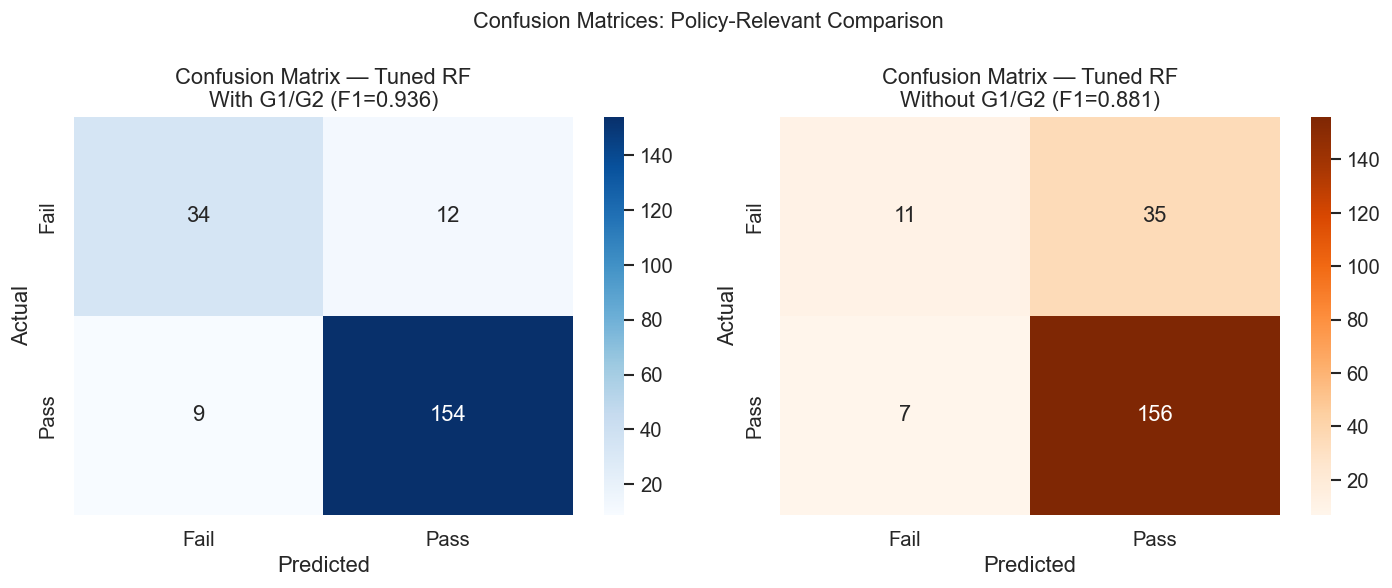

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (scenario, cmap) in zip(axes, [("With G1/G2","Blues"),("Without G1/G2","Oranges")]):
    _, _, y_te_sc, preds_sc, _ = tuned_clf[scenario]
    cm_sc = confusion_matrix(y_te_sc, preds_sc)
    sns.heatmap(cm_sc, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Fail","Pass"], yticklabels=["Fail","Pass"])
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
    ax.set_title(f"Confusion Matrix — Tuned RF\n{scenario} "
                 f"(F1={f1_score(y_te_sc,preds_sc):.3f})")
plt.suptitle("Confusion Matrices: Policy-Relevant Comparison", fontsize=13)
plt.tight_layout(); plt.show()

#### Evaluates precision, recall, and F1 for 80 threshold values from 0.1 to 0.9 for the Without-G1/G2 scenario, identifies the F1-optimal threshold, and plots the trade-off curves
#### The default sklearn threshold of 0.5 is rarely optimal for imbalanced problems. A predict_proba score below 0.5 means the model thinks the student is more likely to fail but at 0.5, we are treating a 49% fail probability as 'safe'. 
#### Lowering the threshold to 0.39 means we flag anyone with ≥39% predicted probability of failing. This increases recall (catching more at-risk students) at the cost of more false alarms.

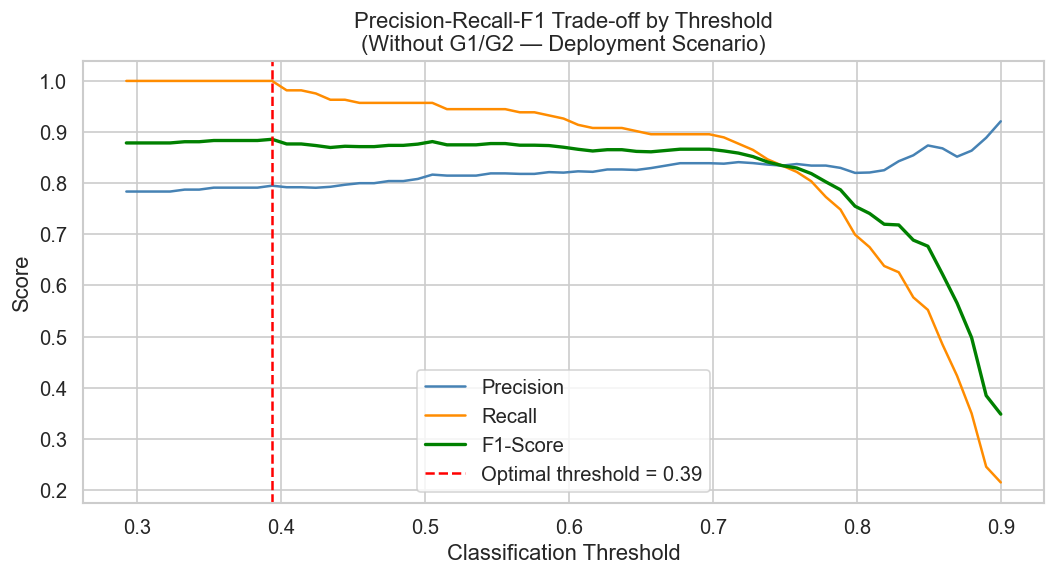

F1-optimal threshold: 0.39  (default is 0.5)


In [20]:
_, _, y_te_wo, preds_wo, proba_wo = tuned_clf["Without G1/G2"]

thresholds = np.linspace(0.1, 0.9, 80)
th_rows = []
for thr in thresholds:
    p_th = (proba_wo >= thr).astype(int)
    if p_th.sum() == 0 or p_th.sum() == len(p_th):
        continue
    th_rows.append({
        "threshold": thr,
        "precision": precision_score(y_te_wo, p_th, zero_division=0),
        "recall":    recall_score(y_te_wo, p_th, zero_division=0),
        "f1":        f1_score(y_te_wo, p_th, zero_division=0),
    })
th_df = pd.DataFrame(th_rows)
opt_threshold = th_df.loc[th_df["f1"].idxmax(), "threshold"]

plt.figure(figsize=(9, 5))
plt.plot(th_df["threshold"], th_df["precision"], label="Precision", color="steelblue")
plt.plot(th_df["threshold"], th_df["recall"],    label="Recall",    color="darkorange")
plt.plot(th_df["threshold"], th_df["f1"],        label="F1-Score",  color="green", lw=2)
plt.axvline(opt_threshold, color="red", linestyle="--",
            label=f"Optimal threshold = {opt_threshold:.2f}")
plt.xlabel("Classification Threshold"); plt.ylabel("Score")
plt.title("Precision-Recall-F1 Trade-off by Threshold\n(Without G1/G2 — Deployment Scenario)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"F1-optimal threshold: {opt_threshold:.2f}  (default is 0.5)")

#### Computes permutation importance for the tuned Random Forest trained without G1/G2 (Scenario B), revealing which behavioural and demographic features drive the without-grades prediction
#### This cell answers RQ3's sub-question: 'when we cannot use grades, which features should schools monitor at enrolment?' The permutation importance is computed on the test set, ensuring we measure real generalisation impact rather than training-set memorisation

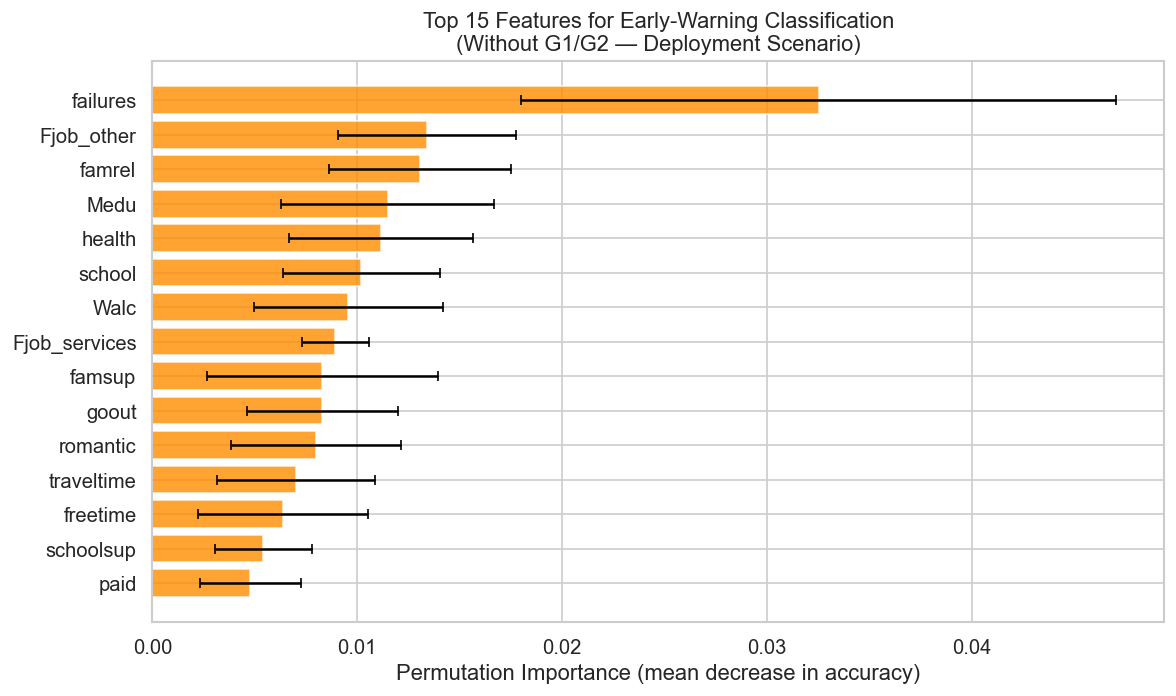

In [21]:
best_rfc_wo, X_te_wo_fi, y_te_wo_fi, _, _ = tuned_clf["Without G1/G2"]
perm_c = permutation_importance(best_rfc_wo, X_te_wo_fi, y_te_wo_fi,
                                n_repeats=15, random_state=RANDOM_STATE)
perm_c_df = pd.DataFrame({
    "Feature":    best_rfc_wo.feature_names_in_,
    "Importance": perm_c.importances_mean,
    "Std":        perm_c.importances_std
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(perm_c_df["Feature"].values[::-1], perm_c_df["Importance"].values[::-1],
         xerr=perm_c_df["Std"].values[::-1], color="darkorange", alpha=0.8,
         capsize=3, ecolor="black")
plt.xlabel("Permutation Importance (mean decrease in accuracy)")
plt.title("Top 15 Features for Early-Warning Classification\n(Without G1/G2 — Deployment Scenario)")
plt.tight_layout(); plt.show()

#### Trains a shallow depth-4 Decision Tree without G1/G2 and prints its full rule set as human-readable text which is best for non-technical school staff.
#### max_depth=4 produces a tree with at most 16 leaf nodes which is complex enough to capture meaningful patterns

In [22]:
drop_c_wo = ["G3","pass","cluster","G1","G2"]
X_c_wo = df_enc.drop(columns=[c for c in drop_c_wo if c in df_enc.columns])
y_c_wo = df_enc["pass"]
X_tr_wo, X_te_wo2, y_tr_wo, y_te_wo2 = train_test_split(
    X_c_wo, y_c_wo, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c_wo)

dt_simple = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt_simple.fit(X_tr_wo, y_tr_wo)
acc_dt = accuracy_score(y_te_wo2, dt_simple.predict(X_te_wo2))
print(f"Interpretable Decision Tree (depth=4, no G1/G2)  Accuracy = {acc_dt:.4f}")
print("\nDecision Rules:")
print(export_text(dt_simple, feature_names=list(X_c_wo.columns), max_depth=3))

Interpretable Decision Tree (depth=4, no G1/G2)  Accuracy = 0.7943

Decision Rules:
|--- failures <= 0.50
|   |--- absences <= 21.50
|   |   |--- higher <= 0.50
|   |   |   |--- famsize <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- famsize >  0.50
|   |   |   |   |--- class: 0
|   |   |--- higher >  0.50
|   |   |   |--- paid <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- paid >  0.50
|   |   |   |   |--- class: 1
|   |--- absences >  21.50
|   |   |--- reason_home <= 0.50
|   |   |   |--- absences <= 44.00
|   |   |   |   |--- class: 1
|   |   |   |--- absences >  44.00
|   |   |   |   |--- class: 0
|   |   |--- reason_home >  0.50
|   |   |   |--- Walc <= 3.50
|   |   |   |   |--- class: 0
|   |   |   |--- Walc >  3.50
|   |   |   |   |--- class: 0
|--- failures >  0.50
|   |--- absences <= 3.50
|   |   |--- freetime <= 3.50
|   |   |   |--- schoolsup <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- schoolsup >  0.50
|   |   |   |   |--- class: 1
|   |   |--- f

#### Tests whether a Logistic Regression model trained on one subject's students can predict pass/fail for the other subject's students, using only shared non-grade features.
#### The model is trained on one subject and evaluated on a completely different population of students doing a different subject. The set intersection of columns finds only the features present in both encoded datasets

In [23]:
def encode_df(raw):
    d = raw.copy()
    for col in binary_cols:
        d[col] = le.fit_transform(d[col])
    d = pd.get_dummies(d, columns=nominal_cols, drop_first=True)
    for g in ["G1","G2","G3"]:
        d[g] = pd.to_numeric(d[g], errors="coerce")
    d.dropna(inplace=True)
    d["pass"] = (d["G3"] >= 10).astype(int)
    return d

mat_e = encode_df(mat.drop(columns=["subject"], errors="ignore"))
por_e = encode_df(por.drop(columns=["subject"], errors="ignore"))
shared = list(set(mat_e.columns) & set(por_e.columns) - {"G1","G2","G3","pass"})
print(f"Shared features (excluding grades): {len(shared)}")

for tr_name, tr_df, te_name, te_df in [
    ("Maths", mat_e, "Portuguese", por_e),
    ("Portuguese", por_e, "Maths", mat_e)
]:
    sc_x = StandardScaler()
    lr_x = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
    lr_x.fit(sc_x.fit_transform(tr_df[shared]), tr_df["pass"])
    preds_x = lr_x.predict(sc_x.transform(te_df[shared]))
    print(f"Train: {tr_name:<12} -> Test: {te_name:<12}  "
          f"Acc={accuracy_score(te_df['pass'],preds_x):.4f}  "
          f"F1={f1_score(te_df['pass'],preds_x):.4f}")

Shared features (excluding grades): 39
Train: Maths        -> Test: Portuguese    Acc=0.7350  F1=0.8327
Train: Portuguese   -> Test: Maths         Acc=0.7089  F1=0.8177


#### Collects all key metrics computed across the notebook and prints a structured summary report

In [24]:
rmse_with_val    = all_reg_tables["With G1/G2"][0]["RMSE"].min()
rmse_without_val = all_reg_tables["Without G1/G2"][0]["RMSE"].min()
r2_without_val   = all_reg_tables["Without G1/G2"][0]["R2"].max()
_, _, y_te_w2, preds_w2, proba_w2 = tuned_clf["With G1/G2"]
_, _, y_te_wo2, preds_wo2, proba_wo2 = tuned_clf["Without G1/G2"]
acc_w2  = accuracy_score(y_te_w2, preds_w2)
auc_w2  = auc(*roc_curve(y_te_w2, proba_w2)[:2])
acc_wo2 = accuracy_score(y_te_wo2, preds_wo2)
auc_wo2 = auc(*roc_curve(y_te_wo2, proba_wo2)[:2])

print(f"""
======================================================================
 FINAL SUMMARY
======================================================================

 UNSUPERVISED LEARNING
  Optimal K           : {best_k}
  Silhouette Score    : {max(sils):.4f}
  Kruskal-Wallis test : H={stat_kw:.2f}, p={p_kw:.4f}  [significant]

 REGRESSION (Predicting G3)
  RMSE with G1/G2     : {rmse_tuned:.4f}  [Tuned Random Forest]
  RMSE without G1/G2  : {rmse_without_val:.4f}
  R2   without G1/G2  : {r2_without_val:.4f}

 CLASSIFICATION (Pass/Fail)
  Accuracy (with G1/G2)    : {acc_w2:.4f}
  AUC      (with G1/G2)    : {auc_w2:.4f}
  Accuracy (without G1/G2) : {acc_wo2:.4f}
  AUC      (without G1/G2) : {auc_wo2:.4f}
  Optimal threshold        : {opt_threshold:.2f}
======================================================================
""")


 FINAL SUMMARY

 UNSUPERVISED LEARNING
  Optimal K           : 2
  Silhouette Score    : 0.1180
  Kruskal-Wallis test : H=106.63, p=0.0000  [significant]

 REGRESSION (Predicting G3)
  RMSE with G1/G2     : 1.6694  [Tuned Random Forest]
  RMSE without G1/G2  : 3.3970
  R2   without G1/G2  : 0.2536

 CLASSIFICATION (Pass/Fail)
  Accuracy (with G1/G2)    : 0.8995
  AUC      (with G1/G2)    : 0.9560
  Accuracy (without G1/G2) : 0.7990
  AUC      (without G1/G2) : 0.6633
  Optimal threshold        : 0.39

